# Code to train model on recognizing different hand signs.

In [1]:
import pickle
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import sys
from tqdm.notebook import tqdm
import os
MAIN_DIR = os.path.dirname(os.path.abspath('__file__'))

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, random_split
import torchvision
import torchvision.transforms as transforms
from torchvision.datasets import ImageFolder
import timm

In [2]:
DEVICE = torch.accelerator.current_accelerator().type if torch.accelerator.is_available() else "cpu"
print(f"Using {DEVICE} device")

Using cuda device


# Dataset Generation

In [3]:
#load data
data_dict = pickle.load(open('data.p', 'rb'))

data = data_dict['data']
labels = data_dict['labels']

In [4]:
print(data[0])

[[0.05405224859714508, 0.2485637664794922], [0.11777696013450623, 0.19740700721740723], [0.16241133213043213, 0.1021648645401001], [0.17584717273712158, 0.031349241733551025], [0.20924347639083862, 0.0], [0.11227193474769592, 0.03132849931716919], [0.14113441109657288, 0.01705801486968994], [0.12799271941184998, 0.08550864458084106], [0.11103209853172302, 0.07815748453140259], [0.0655839741230011, 0.03337186574935913], [0.10148820281028748, 0.023710966110229492], [0.09747856855392456, 0.09746432304382324], [0.08240163326263428, 0.08256357908248901], [0.030679628252983093, 0.05399584770202637], [0.05984079837799072, 0.040745317935943604], [0.06809684634208679, 0.10839802026748657], [0.05354344844818115, 0.10113847255706787], [0.0, 0.0731661319732666], [0.02292369306087494, 0.07013505697250366], [0.03552928566932678, 0.1116449236869812], [0.024874895811080933, 0.11058926582336426]]


In [5]:
class SignDataset(Dataset):
    def __init__(self, data, labels):
        self.data = [torch.tensor(seq, dtype=torch.float32).flatten() for seq in data]
        self.labels = torch.tensor([int(label) for label in labels], dtype=torch.long)

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        return self.data[idx], self.labels[idx]

    @property
    def classes(self):
        return self.data.classes

In [6]:
dataset = SignDataset(data, labels)
len(dataset)

3517

In [7]:
landmarks, label = dataset[3000]
print(landmarks)
print(label)

tensor([0.0000, 0.1295, 0.0029, 0.0528, 0.0320, 0.0039, 0.0712, 0.0020, 0.0972,
        0.0237, 0.0768, 0.0086, 0.1391, 0.0000, 0.1749, 0.0011, 0.2022, 0.0043,
        0.0958, 0.0542, 0.1261, 0.0363, 0.1092, 0.0343, 0.0887, 0.0432, 0.1003,
        0.0951, 0.1157, 0.0713, 0.1025, 0.0716, 0.0841, 0.0815, 0.0984, 0.1278,
        0.1060, 0.1036, 0.0931, 0.1057, 0.0784, 0.1143])
tensor(6)


In [8]:
#Split train and validation dataset
train_dataset, test_dataset = random_split(dataset, [0.8, 0.2])
print(len(train_dataset))
print(len(test_dataset))

2814
703


# DataLoader Generation

In [9]:
train_dataloader = DataLoader(dataset, batch_size = 2814, shuffle = True)
test_dataloader = DataLoader(test_dataset, batch_size = 703, shuffle = True)

In [10]:
for data, label in train_dataloader:
    break

In [11]:
# 2814 datapoints, 21 landmarks [x, y] flatten to become shape 42
print(data.shape)

torch.Size([2814, 42])


In [12]:
print(label.shape)

torch.Size([2814])


# Neural Network Construction

In [13]:
class NeuralNetwork(nn.Module):
    def __init__(self):
        super(NeuralNetwork, self).__init__()
        self.net = nn.Sequential(
            nn.Linear(2*21, 100),
            nn.ReLU(),
            nn.Linear(100, 160),
            nn.ReLU(),
            nn.Linear(160, 26),
            nn.LogSoftmax(dim = 1)
        )

    def forward(self, x):
        return self.net(x)

In [14]:
model = NeuralNetwork()
print(model)

NeuralNetwork(
  (net): Sequential(
    (0): Linear(in_features=42, out_features=100, bias=True)
    (1): ReLU()
    (2): Linear(in_features=100, out_features=160, bias=True)
    (3): ReLU()
    (4): Linear(in_features=160, out_features=26, bias=True)
    (5): LogSoftmax(dim=1)
  )
)


In [15]:
ex_output = model(data)
ex_output.shape # [batch_size, num_classes]

torch.Size([2814, 26])

# Loss & Optimizer

In [16]:
#Loss
criterion = nn.CrossEntropyLoss()
#Optimizer
optimizer = optim.Adam(model.parameters(), lr = 0.001)

In [17]:
criterion(ex_output, label)

tensor(3.2591, grad_fn=<NllLossBackward0>)

In [18]:
print(optimizer)

Adam (
Parameter Group 0
    amsgrad: False
    betas: (0.9, 0.999)
    capturable: False
    decoupled_weight_decay: False
    differentiable: False
    eps: 1e-08
    foreach: None
    fused: None
    lr: 0.001
    maximize: False
    weight_decay: 0
)


# Load Pre-trained Model

In [26]:
def load_checkpoint(filename: str, model: object, optimizer: object, epoch: int, train_loss: float, val_loss: float) -> (object, object): 
    print("Loading checkpoint")
    checkpoint = torch.load(filename)
    model.load_state_dict(checkpoint['state_dict'])
    optimizer.load_state_dict(checkpoint['optimizer'])
    epoch = checkpoint['epoch']
    train_loss = checkpoint['train_loss']
    val_loss = checkpoint['validation_loss']
    #If save more things, get more from the dict and then return
    return model, optimizer, epoch, train_loss, val_loss

In [27]:
epoch, train_loss, val_loss = 0, 0, 0

In [28]:
model, optimizer, epoch, train_loss, val_loss = load_checkpoint("model_checkpoint.pth.rar", model, optimizer, epoch, train_loss, val_loss)

Loading checkpoint


In [29]:
model

NeuralNetwork(
  (net): Sequential(
    (0): Linear(in_features=42, out_features=100, bias=True)
    (1): ReLU()
    (2): Linear(in_features=100, out_features=160, bias=True)
    (3): ReLU()
    (4): Linear(in_features=160, out_features=26, bias=True)
    (5): LogSoftmax(dim=1)
  )
)

In [30]:
print(optimizer)

Adam (
Parameter Group 0
    amsgrad: False
    betas: (0.9, 0.999)
    capturable: False
    decoupled_weight_decay: False
    differentiable: False
    eps: 1e-08
    foreach: None
    fused: None
    lr: 0.001
    maximize: False
    weight_decay: 0
)


In [31]:
print(epoch)
print(train_loss)
print(val_loss)

199
0.08240226972027384
0.08649457157433697


# Continue Model Training

In [32]:
num_epochs = 100
train_losses, val_losses = [], []

model.to(DEVICE)

for epoch in range(num_epochs):
    model.train() #setting model mode .train or .eval
    running_loss = 0.0
    for landmarks, labels in tqdm(train_dataloader, desc = "Training loop"):
        landmarks, labels = landmarks.to(DEVICE), labels.to(DEVICE)

        optimizer.zero_grad()
        outputs = model(landmarks)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        running_loss += loss.item() * labels.size(0)
    train_loss = running_loss / len(train_dataloader.dataset)
    train_losses.append(train_loss)

    #Validation phase
    model.eval()
    running_loss = 0.0
    with torch.no_grad():
        for landmarks, labels in tqdm(test_dataloader, desc = "Validation loop"):
            landmarks, labels = landmarks.to(DEVICE), labels.to(DEVICE)
            outputs = model(landmarks)
            loss = criterion(outputs, labels)
            running_loss += loss.item() * labels.size(0)
    val_loss = running_loss / len(test_dataloader.dataset)
    val_losses.append(val_loss)

    print("Epoch %d out of %s - Train loss: %s , Validation loss: %s" % (epoch + 1, num_epochs, train_loss, val_loss))

Training loop:   0%|          | 0/2 [00:00<?, ?it/s]

Validation loop:   0%|          | 0/1 [00:00<?, ?it/s]

Epoch 1 out of 100 - Train loss: 0.31487131986914285 , Validation loss: 0.1853453814983368


Training loop:   0%|          | 0/2 [00:00<?, ?it/s]

Validation loop:   0%|          | 0/1 [00:00<?, ?it/s]

...

Validation loop:   0%|          | 0/1 [00:00<?, ?it/s]

Epoch 99 out of 100 - Train loss: 0.010990305767702572 , Validation loss: 0.010290592908859253


Training loop:   0%|          | 0/2 [00:00<?, ?it/s]

Validation loop:   0%|          | 0/1 [00:00<?, ?it/s]

Epoch 100 out of 100 - Train loss: 0.010948059284931935 , Validation loss: 0.010409010574221611


# Visualize

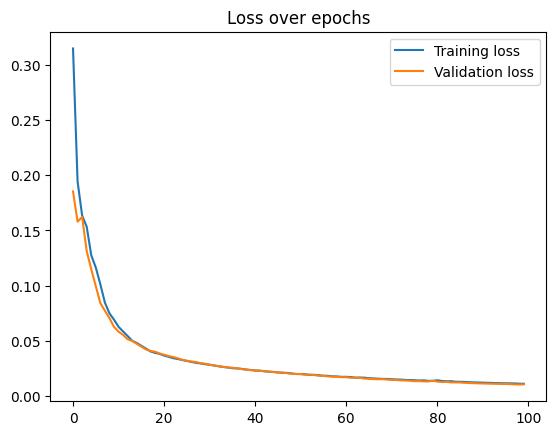

In [33]:
plt.plot(train_losses, label='Training loss')
plt.plot(val_losses, label='Validation loss')
plt.legend()
plt.title("Loss over epochs")
plt.show()

# Save Model State for Further Training Later

In [34]:
checkpoint = {'state_dict' : model. state_dict(), 'optimizer': optimizer.state_dict()}

In [35]:
def save_checkpoint(state, filename = "model_checkpoint_2_1.pth.rar"):
    print("Saving current checkpoint")
    torch.save(state, filename)

In [36]:
save_checkpoint(checkpoint)

Saving current checkpoint


# Save Model for inferencing

In [37]:
# Save model for model inference
# Save the model's state_dict
model_scripted = torch.jit.script(model) # Export to TorchScript
model_scripted.save('model_2_1.pth.rar') # Save

# Test Trained model

In [38]:
import mediapipe as mp
import cv2

mp_hands = mp.solutions.hands
mp_drawing = mp.solutions.drawing_utils
mp_drawing_styles = mp.solutions.drawing_styles

hands = mp_hands.Hands(static_image_mode=True, min_detection_confidence=0.6, max_num_hands = 1)

In [39]:
def predict(model, input_landmarks):
    model.eval()
    with torch.no_grad():
        input_landmarks = torch.tensor(input_landmarks, dtype=torch.float32).flatten()
        input_landmarks = input_landmarks.unsqueeze(0).to(DEVICE)
        predictions_log = model(input_landmarks)
        predictions_prob = torch.exp(predictions_log)
        max_probability_predicted, max_probability_index = torch.max(predictions_prob, dim=1)
    return max_probability_index.item()

In [40]:
def hand_landmarks_detection(path: str) -> list:
    data_aux, x_, y_ = [], [], []

    img = cv2.imread(path)
    # Flip image horizontally to correctly identify left hand being used in the collected images
    #img = cv2.flip(img, 1)
    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    results = hands.process(img_rgb)

    # Only use the images with left hand for dataset generation => only 21 points for landmarks
    if results.multi_hand_landmarks and results.multi_handedness[0].classification[0].label == 'Left':
        for hand_landmarks in results.multi_hand_landmarks:
            # Write images with overlapped hand landmarks on the original data collected.
            mp_drawing.draw_landmarks(
                img,
                hand_landmarks,
                mp_hands.HAND_CONNECTIONS,  
                mp_drawing_styles.get_default_hand_landmarks_style(),
                mp_drawing_styles.get_default_hand_connections_style())
            
            for i in range(len(hand_landmarks.landmark)):
                x = hand_landmarks.landmark[i].x
                y = hand_landmarks.landmark[i].y

                x_.append(x)
                y_.append(y)

        # To reduce variability for different positions of the hand on the screen, each data point subtracts the lowest x and y position per frame.
        # Essentially reducing the positions of all landmarks to be start at the bottom left conner of the image.
        for i in range(len(hand_landmarks.landmark)):
            x = hand_landmarks.landmark[i].x
            y = hand_landmarks.landmark[i].y
            data_aux.append([x - min(x_), y - min(y_)])
    return data_aux
        

In [41]:
test_folder = "neural_net_model_test_set"
counter = correct_points = 0
for char_folder in os.listdir(test_folder):
    correct_result = char_folder
    for pic in os.listdir(os.path.join(test_folder, char_folder)):
        hand_landmarks = hand_landmarks_detection(os.path.join(test_folder, char_folder, pic))
        if hand_landmarks:
            counter += 1
            predicted_result = predict(model, hand_landmarks)
            if str(predicted_result) == char_folder:
                correct_points += 1

print(counter)
print(correct_points)
print("Accuracy: " + str(correct_points/counter))
        

223
211
Accuracy: 0.9461883408071748
